# Spam Intelligence Studio Report

This notebook documents the multi-dataset spam-filtering pipeline. It uses package code from `spam_intelligence` so the analysis stays reproducible and aligned with the CLI artifacts.

In [5]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

def _resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'spam_intelligence').exists():
            return candidate

    # Fallback for VS Code kernels launched outside the workspace tree.
    known_root = Path('d:/Message Spam Filtering')
    if (known_root / 'pyproject.toml').exists() and (known_root / 'src' / 'spam_intelligence').exists():
        return known_root

    return cwd

ROOT = _resolve_project_root()
SRC = ROOT / 'src'
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spam_intelligence.data import dataset_audit, load_corpus
from spam_intelligence.predict import predict_messages

CORPUS_PATH = ROOT / 'data' / 'processed' / 'message_corpus.csv'
CLASSICAL_DIR = ROOT / 'artifacts' / 'classical'
TRANSFORMER_DIR = ROOT / 'artifacts' / 'transformer'

corpus = load_corpus(CORPUS_PATH)
corpus.head()

,text,label,channel,source,split
0,"Go until jurong point, crazy.. Available only ...",ham,sms,uci_sms_spam_collection,train
1,Ok lar... Joking wif u oni...,ham,sms,uci_sms_spam_collection,train
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,sms,uci_sms_spam_collection,train
3,U dun say so early hor... U c already then say...,ham,sms,uci_sms_spam_collection,validation
4,"Nah I don't think he goes to usf, he lives aro...",ham,sms,uci_sms_spam_collection,train


## Dataset Audit

The merged corpus contains SMS and email data, with split assignments already generated in the package layer.

In [6]:
audit = dataset_audit(corpus)
display(audit)
display(corpus.groupby(['channel', 'label', 'split']).size().rename('records').reset_index())

,source,channel,label,records,average_length
0,20021010_easy_ham,email,ham,2408,1388.290282
1,20021010_hard_ham,email,ham,231,6930.181818
2,20021010_spam,email,spam,471,2493.343949
3,20030228_easy_ham_2,email,ham,1389,1757.022318
4,20050311_spam_2,email,spam,1328,2326.689759
5,uci_sms_spam_collection,sms,ham,4515,69.911628
6,uci_sms_spam_collection,sms,spam,642,137.591900


,channel,label,split,records
0,email,ham,test,605
1,email,ham,train,2819
2,email,ham,validation,604
3,email,spam,test,270
4,email,spam,train,1259
5,email,spam,validation,270
6,sms,ham,test,677
7,sms,ham,train,3160
8,sms,ham,validation,678
9,sms,spam,test,96


## Classical Benchmark

The classical benchmark combines word TF-IDF, character TF-IDF, and metadata features such as message length, punctuation density, URLs, phone-like patterns, and promotional keywords.

In [7]:
validation_metrics = pd.read_csv(CLASSICAL_DIR / 'validation_metrics.csv')
test_metrics = pd.read_csv(CLASSICAL_DIR / 'test_metrics.csv')
display(validation_metrics)
display(test_metrics)

,model,accuracy,macro_f1,spam_precision,spam_recall,pr_auc,composite_score
0,logistic_regression,0.979369,0.970146,0.953552,0.953552,0.969899,0.966227
1,random_forest,0.973908,0.960881,0.987915,0.893443,0.986271,0.948703
2,complement_nb,0.945388,0.922616,0.855670,0.907104,0.852084,0.885447
3,linear_svc,0.835558,0.737576,0.672727,0.505464,0.627160,0.606650


,model,accuracy,macro_f1,spam_precision,spam_recall,pr_auc,composite_score
0,logistic_regression,0.978155,0.968265,0.955801,0.945355,0.983025,0.968889
1,random_forest,0.976942,0.965892,0.976744,0.918033,0.985556,0.957990
2,complement_nb,0.950850,0.928243,0.899160,0.877049,0.891753,0.893905
3,linear_svc,0.833131,0.733702,0.665455,0.500000,0.668452,0.622544


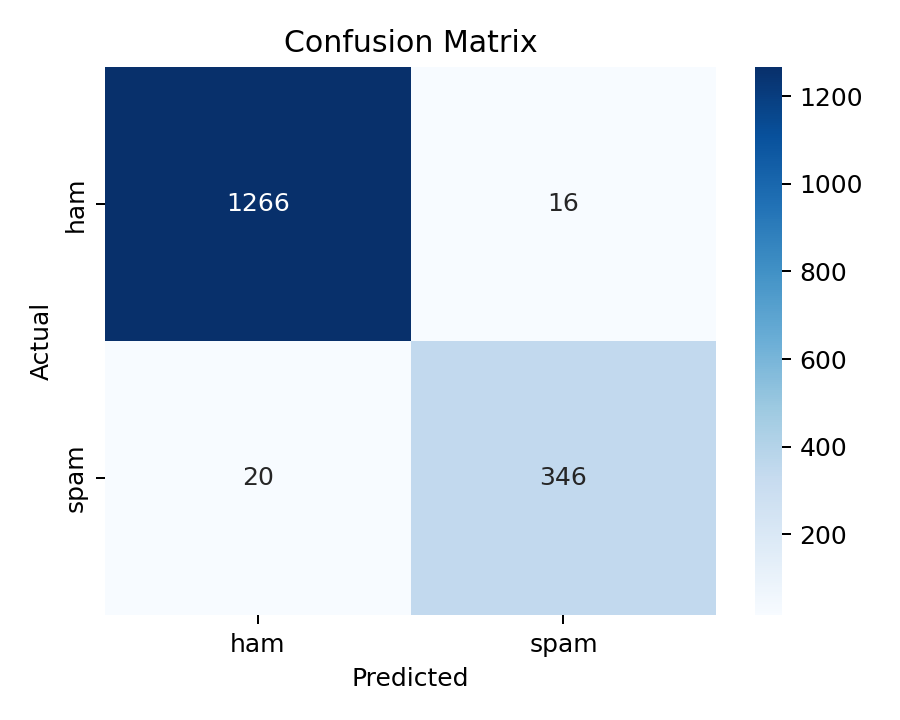

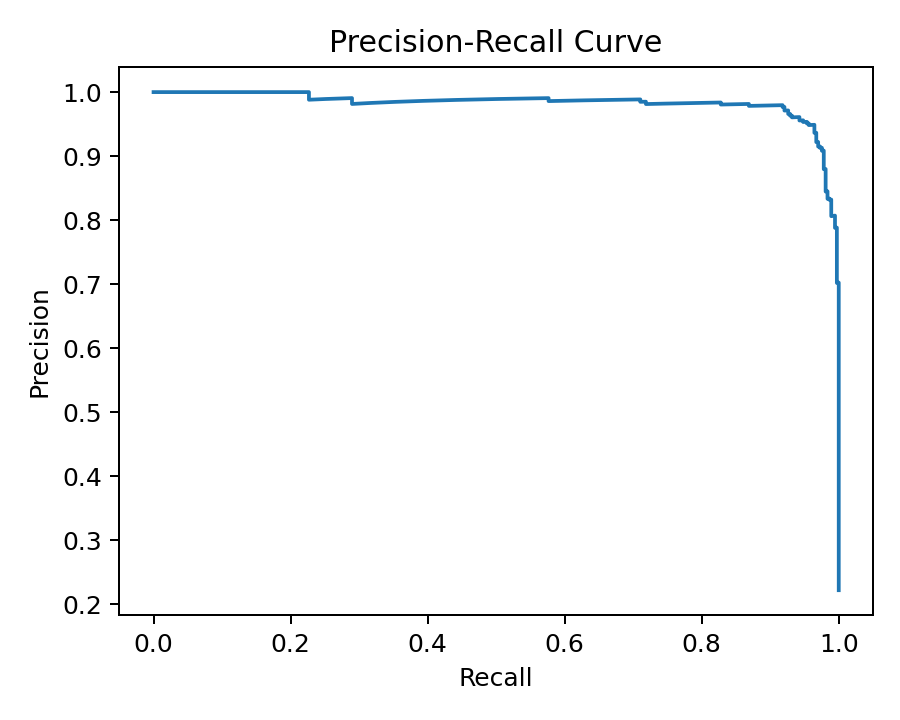

In [8]:
for image_name in ['confusion_matrix.png', 'precision_recall_curve.png']:
    image_path = CLASSICAL_DIR / image_name
    if image_path.exists():
        display(Image(filename=str(image_path)))

## Error Analysis

These tables surface representative false positives and false negatives from the best classical model.

In [9]:
false_positives = pd.read_csv(CLASSICAL_DIR / 'false_positives.csv')
false_negatives = pd.read_csv(CLASSICAL_DIR / 'false_negatives.csv')
top_linear = json.loads((CLASSICAL_DIR / 'top_linear_features.json').read_text(encoding='utf-8'))
display(false_positives)
display(false_negatives)
pd.DataFrame(top_linear['positive']).head(10)

,text,label,channel,source,predicted_label,spam_score
0,Hi! You just spoke to MANEESHA V. We'd like to...,ham,sms,uci_sms_spam_collection,spam,0.616934
1,Are you free now?can i call now?,ham,sms,uci_sms_spam_collection,spam,0.583834
2,Talk With Yourself Atleast Once In A Day...!!!...,ham,sms,uci_sms_spam_collection,spam,0.706955
3,HCL chennai requires FRESHERS for voice proces...,ham,sms,uci_sms_spam_collection,spam,0.521341
4,Many times we lose our best ones bcoz we are,ham,sms,uci_sms_spam_collection,spam,0.518099
5,PGP Corp. Purchases PGP Desktop Encryption and...,ham,email,20030228_easy_ham_2,spam,0.612306
6,Get the Perfect Mix of ZDNet's Best Stuff! ZDN...,ham,email,20021010_hard_ham,spam,0.646380
7,Take all your music on the road (ZDNET SHOPPER...,ham,email,20021010_hard_ham,spam,0.644730
8,FREE SHIPPING! No Minimum Purchase* at Buy.com...,ham,email,20021010_hard_ham,spam,0.964613
9,Malcolm in the Middle Sweepstakes Prize Notifi...,ham,email,20021010_hard_ham,spam,0.993824


,text,label,channel,source,predicted_label,spam_score
0,FreeMsg Hey there darling it's been 3 week's n...,spam,sms,uci_sms_spam_collection,ham,0.230544
1,SMS. ac sun0819 posts HELLO:\You seem cool,spam,sms,uci_sms_spam_collection,ham,0.192048
2,Win the newest ÛÏHarry Potter and the Order o...,spam,sms,uci_sms_spam_collection,ham,0.398402
3,Hi its LUCY Hubby at meetins all day Fri & I w...,spam,sms,uci_sms_spam_collection,ham,0.264257
4,"SMS. ac JSco: Energy is high, but u may not kn...",spam,sms,uci_sms_spam_collection,ham,0.228824
5,Monthly password for wap. mobsi.com is 391784....,spam,sms,uci_sms_spam_collection,ham,0.487412
6,Back 2 work 2morro half term over! Can U C me ...,spam,sms,uci_sms_spam_collection,ham,0.477454
7,Guess who am I?This is the first time I create...,spam,sms,uci_sms_spam_collection,ham,0.239270
8,ROMCAPspam Everyone around should be respondin...,spam,sms,uci_sms_spam_collection,ham,0.177275
9,Auction round 4. The highest bid is now å£54. ...,spam,sms,uci_sms_spam_collection,ham,0.348086


,feature,weight
0,numeric__digit_ratio,5.458986
1,word_tfidf__txt,2.779133
2,word_tfidf__our,2.131830
3,numeric__uppercase_ratio,1.787353
4,word_tfidf__click here,1.770932
5,word_tfidf__150p,1.707511
6,word_tfidf__your,1.706050
7,char_tfidf__ 08,1.694255
8,word_tfidf__free,1.674419
9,word_tfidf__call,1.636814


## Transformer Benchmark

If the transformer benchmark has been trained, the saved metrics are loaded below.

In [10]:
transformer_metrics_path = TRANSFORMER_DIR / 'transformer_metrics.json'
if transformer_metrics_path.exists():
    transformer_metrics = json.loads(transformer_metrics_path.read_text(encoding='utf-8'))
    display(pd.DataFrame([transformer_metrics]))
else:
    print('Transformer benchmark has not been run yet.')

,eval_loss,eval_macro_f1,eval_spam_precision,eval_spam_recall,eval_pr_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.657013,0.333333,0.5,1.0,0.948594,18.0284,11.094,1.387,0.2


## Deployment-Style Predictions

The package also supports inference outside the notebook.

In [11]:
best_model_path = CLASSICAL_DIR / 'best_model.joblib'
samples = [
    'Urgent! Claim your free cash bonus now by clicking the link.',
    'Can we move tomorrow\'s lunch to 1 PM?'
]
display(pd.DataFrame(predict_messages(best_model_path, samples)))

,text,prediction,confidence,signals
0,Urgent! Claim your free cash bonus now by clic...,spam,0.961511,[contains high-risk promotional language]
1,Can we move tomorrow's lunch to 1 PM?,ham,0.083072,[message language looks conversational and low...
